In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [21]:
# ── Load Data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('appointments.csv', parse_dates=['appointment_date'])
df.rename(columns={'specialty': 'doctor_specialty'}, inplace=True)

print("=== Dataset Overview ===")
print(f"Total Records : {len(df)}")
print(f"Date Range    : {df['appointment_date'].min().date()} → {df['appointment_date'].max().date()}")
print(f"Divisions     : {df['division'].nunique()}")
print(f"Specialties   : {df['doctor_specialty'].nunique()}\n")

print("=== Column Data Types ===")
print(df.dtypes)

print("=== First 3 Rows ===")
df.head(3)


=== Dataset Overview ===
Total Records : 500
Date Range    : 2023-01-02 → 2024-12-26
Divisions     : 8
Specialties   : 6

=== Column Data Types ===
patient_age                      int64
patient_gender                     str
division                           str
doctor_specialty                   str
appointment_status                 str
consultation_fee_bdt             int64
wait_days                        int64
appointment_date        datetime64[us]
dtype: object
=== First 3 Rows ===


,patient_age,patient_gender,division,doctor_specialty,appointment_status,consultation_fee_bdt,wait_days,appointment_date
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27


In [22]:
# ── Basic Cleaning ─────────────────────────────────────────────────────────────
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
patient_age             0
patient_gender          0
division                0
doctor_specialty        0
appointment_status      0
consultation_fee_bdt    0
wait_days               0
appointment_date        0
dtype: int64


In [23]:
# Age group segmentation
bins = [0, 17, 35, 55, 100]
labels = ['Child (0-17)', 'Young Adult (18-35)', 'Middle Age (36-55)', 'Senior (56+)']
df['age_group'] = pd.cut(df['patient_age'], bins=bins, labels=labels)

print("=== First 3 Rows after adding Age Groups column ===")
df.head(3)

=== First 3 Rows after adding Age Groups column ===


,patient_age,patient_gender,division,doctor_specialty,appointment_status,consultation_fee_bdt,wait_days,appointment_date,age_group
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19,Senior (56+)
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07,Young Adult (18-35)
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27,Senior (56+)


In [24]:
# Extract month name for trend analysis
df['month'] = df['appointment_date'].dt.month
df['year'] = df['appointment_date'].dt.year
df['month_name'] = df['appointment_date'].dt.strftime('%b')

print("=== First 3 Rows after adding Month Year columns ===")
df.head(3)

=== First 3 Rows after adding Month Year columns ===


,patient_age,patient_gender,division,doctor_specialty,appointment_status,consultation_fee_bdt,wait_days,appointment_date,age_group,month,year,month_name
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19,Senior (56+),11,2023,Nov
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07,Young Adult (18-35),6,2024,Jun
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27,Senior (56+),2,2023,Feb


In [25]:
# ── Analysis 1: Appointment Status Breakdown ───────────────────────────────────
status_counts = df['appointment_status'].value_counts()
print("=== Appointment Status ===")
print(status_counts.to_string())
print()

=== Appointment Status ===
appointment_status
Completed    343
Cancelled    101
No-show       56



In [26]:
# ── Analysis 2: No-show Rate by Division ──────────────────────────────────────
noshow_by_division = (
    df.assign(is_noshow=(df['appointment_status'] == 'No-show'))
      .groupby('division')['is_noshow']
      .mean()
      .mul(100)
      .round(1)
      .reset_index(name='noshow_rate_pct')
      .sort_values('noshow_rate_pct', ascending=False)
)
noshow_by_division.columns = ['division', 'noshow_rate_pct']
print("=== No-show Rate by Division ===")
print(noshow_by_division.to_string(index=False))
print()

=== No-show Rate by Division ===
  division  noshow_rate_pct
     Dhaka             14.6
Chattogram             13.4
  Rajshahi             11.7
    Sylhet              9.3
Mymensingh              8.0
    Khulna              6.7
  Barishal              4.5
   Rangpur              0.0



In [35]:
# ── Analysis 3: Most In-Demand Specialties ────────────────────────────────────
specialty_demand = df['doctor_specialty'].value_counts().reset_index(name='appointments_count')
print("=== Specialty Demand ===")
print(specialty_demand.to_string(index=False))
print()

=== Specialty Demand ===
 doctor_specialty  appointments_count
     Pediatrician                  92
    Dermatologist                  89
     Cardiologist                  85
General Physician                  84
     Gynecologist                  75
       Orthopedic                  75



In [28]:
# ── Analysis 4: Average Wait Days by Specialty ────────────────────────────────
avg_wait = (
    df.groupby('doctor_specialty')['wait_days']
    .mean()
    .round(1)
    .sort_values(ascending=False)
    .reset_index(name='avg_wait_days')
)
print("=== Average Wait Days by Specialty ===")
print(avg_wait.to_string(index=False))
print()

=== Average Wait Days by Specialty ===
 doctor_specialty  avg_wait_days
General Physician           11.6
     Gynecologist           11.5
       Orthopedic           11.5
    Dermatologist           10.5
     Pediatrician            9.3
     Cardiologist            9.0



In [29]:
# ── Analysis 5: Age Group Distribution ───────────────────────────────────────
age_dist = df['age_group'].value_counts().sort_index().reset_index(name='count')
print("=== Patient Age Group Distribution ===")
print(age_dist.to_string(index=False))
print()

=== Patient Age Group Distribution ===
          age_group  count
       Child (0-17)     90
Young Adult (18-35)    118
 Middle Age (36-55)    130
       Senior (56+)    162



In [30]:
# ── Analysis 6: Monthly Appointment Trend ─────────────────────────────────────
monthly_trend = (
    df.groupby(['year', 'month', 'month_name'])
    .size()
    .reset_index(name='count')
    .sort_values(['year', 'month'])
)
print("=== Monthly Appointment Trend ===")
print(monthly_trend.to_string(index=False))

=== Monthly Appointment Trend ===
 year  month month_name  count
 2023      1        Jan     23
 2023      2        Feb     15
 2023      3        Mar     25
 2023      4        Apr     16
 2023      5        May     26
 2023      6        Jun     24
 2023      7        Jul     16
 2023      8        Aug     15
 2023      9        Sep     15
 2023     10        Oct     23
 2023     11        Nov     29
 2023     12        Dec     18
 2024      1        Jan     21
 2024      2        Feb     22
 2024      3        Mar     23
 2024      4        Apr     18
 2024      5        May     14
 2024      6        Jun     23
 2024      7        Jul     22
 2024      8        Aug     22
 2024      9        Sep     22
 2024     10        Oct     24
 2024     11        Nov     23
 2024     12        Dec     21


In [31]:
# ── Key Findings Summary ───────────────────────────────────────────────────────
print("\n=== Key Findings ===")
top_noshow = noshow_by_division.iloc[0]
top_specialty = specialty_demand.iloc[0]
longest_wait = avg_wait.iloc[0]
completion_rate = round(status_counts.get('Completed', 0) / len(df) * 100, 1)
top_age_group = age_dist.iloc[3]

print(f"• Overall completion rate        : {completion_rate}%")
print(f"• Division with highest no-show  : {top_noshow['division']} ({top_noshow['noshow_rate_pct']}%)")
print(f"• Most visited specialty         : {top_specialty['doctor_specialty']} ({top_specialty['appointments']} appointments)")
print(f"• Longest average wait           : {longest_wait['doctor_specialty']} ({longest_wait['avg_wait_days']} days)")
print(f"• Largest patient group          : {top_age_group['age_group']}")


=== Key Findings ===
• Overall completion rate        : 68.6%
• Division with highest no-show  : Dhaka (14.6%)
• Most visited specialty         : Pediatrician (92 appointments)
• Longest average wait           : General Physician (11.6 days)
• Largest patient group          : Senior (56+)


Chart saved as healthcare_analysis.png


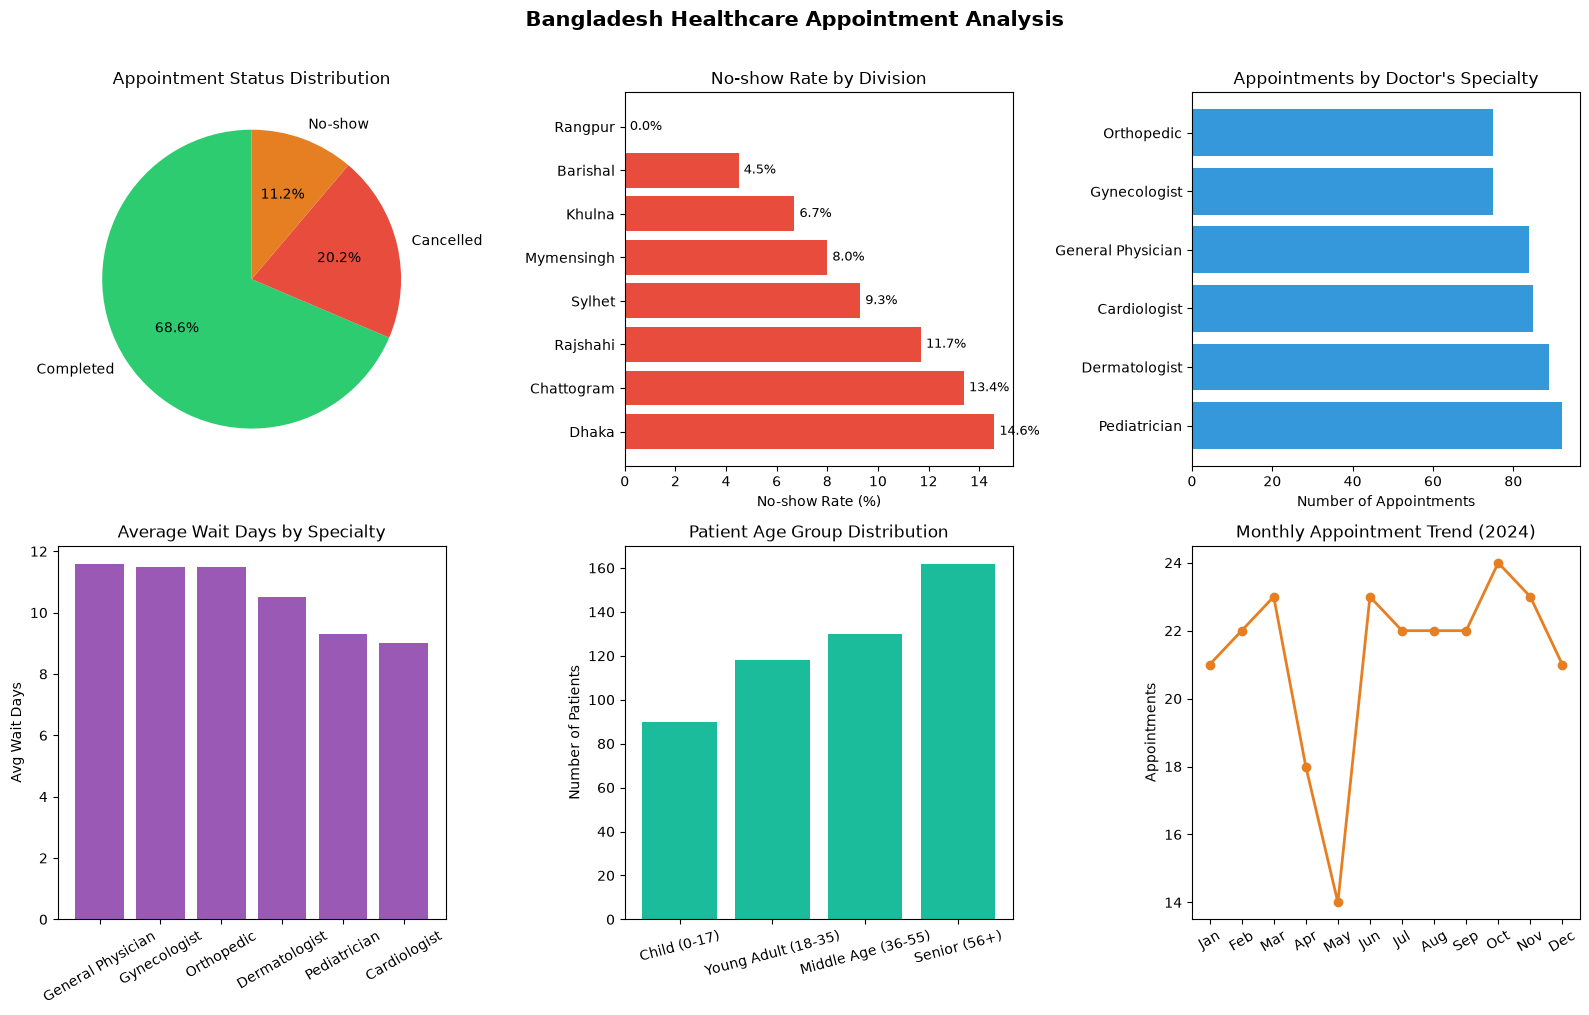

In [ ]:
# ── Visualizations ─────────────────────────────────────────────────────────────
plt.close('all')  # clears out any old figures before drawing a new one

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bangladesh Healthcare Appointment Analysis', fontsize=15, fontweight='bold', y=1.01)

colors_main = ['#2ecc71', '#e74c3c', '#e67e22']
bar_color = '#3498db'

# Plot 1 — Appointment Status
axes[0, 0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_main,
    startangle=90
)
axes[0, 0].set_title('Appointment Status Distribution')

# Plot 2 — No-show Rate by Division
axes[0, 1].barh(
    noshow_by_division['division'],
    noshow_by_division['noshow_rate_pct'],
    color='#e74c3c'
)
axes[0, 1].set_xlabel('No-show Rate (%)')
axes[0, 1].set_title('No-show Rate by Division')
for i, v in enumerate(noshow_by_division['noshow_rate_pct']):
    axes[0, 1].text(v + 0.2, i, f'{v}%', va='center', fontsize=9)
    
# Plot 3 — Specialty Demand
axes[0, 2].barh(
    specialty_demand['doctor_specialty'],
    specialty_demand['appointments_count'],
    color=bar_color
)
axes[0, 2].set_xlabel('Number of Appointments')
axes[0, 2].set_title("Appointments by Doctor's Specialty")

# Plot 4 — Average Wait Days
axes[1, 0].bar(
    avg_wait['doctor_specialty'],
    avg_wait['avg_wait_days'],
    color='#9b59b6'
)
axes[1, 0].set_ylabel('Avg Wait Days')
axes[1, 0].set_title('Average Wait Days by Specialty')
axes[1, 0].tick_params(axis='x', rotation=30)

# Plot 5 — Age Group Distribution
axes[1, 1].bar(
    age_dist['age_group'],
    age_dist['count'],
    color='#1abc9c'
)
axes[1, 1].set_ylabel('Number of Patients')
axes[1, 1].set_title('Patient Age Group Distribution')
axes[1, 1].tick_params(axis='x', rotation=15)

# Plot 6 — Monthly Trend in 2024
trend_2024 = monthly_trend[monthly_trend['year'] == 2024]
axes[1, 2].plot(
    trend_2024['month_name'],
    trend_2024['count'],
    marker='o',
    color='#e67e22',
    linewidth=2
)
axes[1, 2].set_ylabel('Appointments')
axes[1, 2].set_title('Monthly Appointment Trend (2024)')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('healthcare_analysis.png', dpi=150, bbox_inches='tight')
print("Chart saved as healthcare_analysis.png")